# Aligning two visium datasets

In this notebook, we align two Visium spot resolution spatial transcriptomics datasets of mouse kidney can be found Zenodo: https://doi.org/10.5281/zenodo.17676991

Since the H&E is relatively homogenous and we do not have the scaling factor to associate the spot locations with the H&E, we will align based on spot regions annotations determined from transcriptional clustering.


We will use `STalign` to achieve this alignment. We will first load the relevant code libraries.

In [1]:
## import dependencies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import plotly
import requests

# make plots bigger
plt.rcParams["figure.figsize"] = (12,10)

In [7]:
# OPTION A: import STalign after pip or pipenv install
from STalign import STalign

In [6]:
## OPTION B: skip cell if installed STalign with pip or pipenv
import sys
#sys.path.append("../../STalign") 
sys.path.append("~/STalign/STalign") 

## import STalign from upper directory
import STalign

ModuleNotFoundError: No module named 'STalign'


We can read in the information for the first dataset using `pandas` as `pd`.

In [141]:
# data 1
# read in data
fname = '~/ST_compare/data/kidney_data/ctrl_region_onehot.csv'
df1 = pd.read_csv(fname, index_col=0)
print(df1.head())

                      x   y    group  cortex  interface  medulla  other
AAACAAGTATCTCCCA-1  102  50  Control       1          0        0      0
AAACAGAGCGACTCCT-1   94  14  Control       1          0        0      0
AAACAGCTTTCAGAAG-1    9  43  Control       1          0        0      0
AAACAGGGTCTATATT-1   13  47  Control       1          0        0      0
AAACATTTCCCGGATT-1   97  61  Control       1          0        0      0


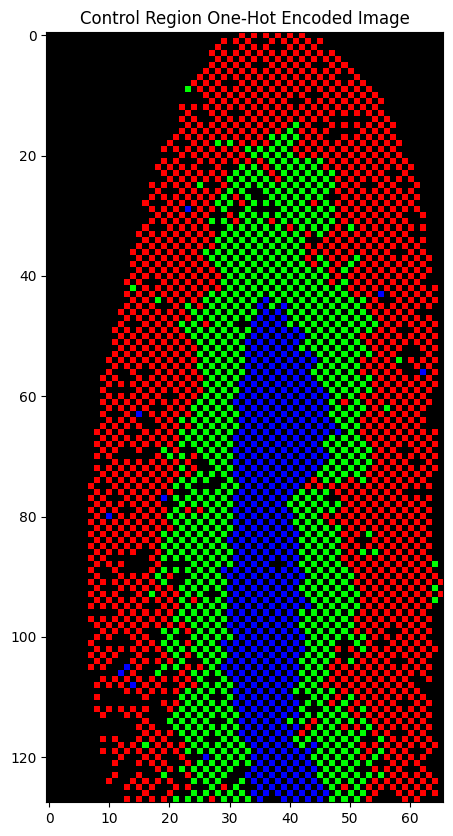

In [142]:
# convert df1 to image with 3 channels (one for cortex, one for interface, and one for medulla) using the x as the row index and the y as the column index
# create an empty image with 3 channels
img1 = np.zeros((df1['x'].max()+1, df1['y'].max()+1, 3))
# iterate through the rows of the dataframe and fill in the image
for index, row in df1.iterrows():
    x = row['x']
    y = row['y']
    cortex = row['cortex']
    interface = row['interface']
    medulla = row['medulla']
    if cortex == 1:
        img1[x, y, 0] = 1
    elif interface == 1:
        img1[x, y, 1] = 1
    elif medulla == 1:
        img1[x, y, 2] = 1   

# plot the image
plt.imshow(img1)
plt.title('Control Region One-Hot Encoded Image')
plt.show()

Now, we can repeat this to get cell information from the second dataset.

                      x   y group  cortex  interface  medulla  other
AAACAAGTATCTCCCA-1  102  50   AKI       0          0        1      0
AAACAGAGCGACTCCT-1   94  14   AKI       1          0        0      0
AAACAGCTTTCAGAAG-1    9  43   AKI       1          0        0      0
AAACAGGGTCTATATT-1   13  47   AKI       1          0        0      0
AAACATTTCCCGGATT-1   97  61   AKI       0          1        0      0


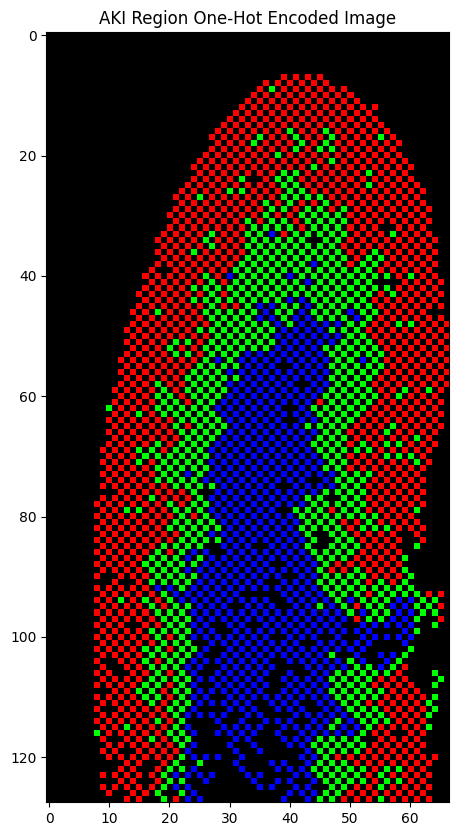

In [143]:
# data 2
# read in data
fname = '~/ST_compare/data/kidney_data/aki_region_onehot.csv'
df2 = pd.read_csv(fname, index_col=0)
print(df2.head())

# convert df2 to image with 3 channels (one for cortex, one for interface, and one for medulla) using the x as the row index and the y as the column index
# create an empty image with 3 channels
img2 = np.zeros((df2['x'].max()+1, df2['y'].max()+1, 3))
# iterate through the rows of the dataframe and fill in the image
for index, row in df2.iterrows():
    x = row['x']
    y = row['y']
    cortex = row['cortex']
    interface = row['interface']
    medulla = row['medulla']
    if cortex == 1:
        img2[x, y, 0] = 1
    elif interface == 1:
        img2[x, y, 1] = 1
    elif medulla == 1:
        img2    [x, y, 2] = 1   

# plot the image
plt.imshow(img2)
plt.title('AKI Region One-Hot Encoded Image')
plt.show()

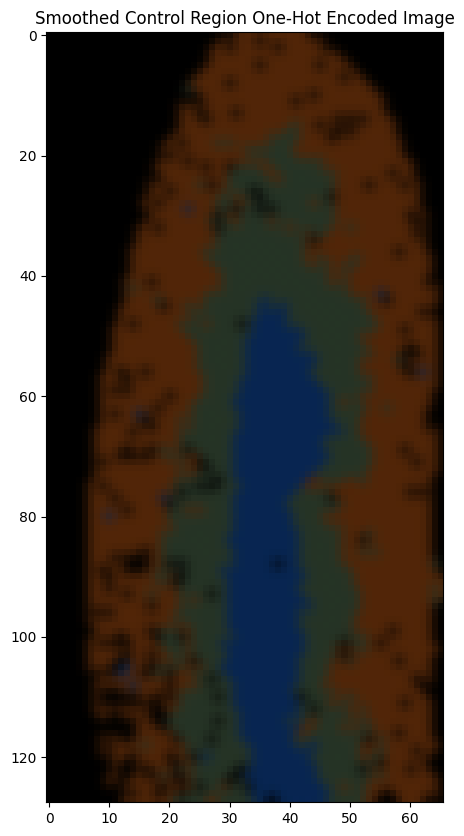

In [144]:
# smooth the image with a gaussian filter
from scipy.ndimage import gaussian_filter
img1 = gaussian_filter(img1, sigma=1)

#plot the smoothed image
plt.imshow(img1)
plt.title('Smoothed Control Region One-Hot Encoded Image')
plt.show()

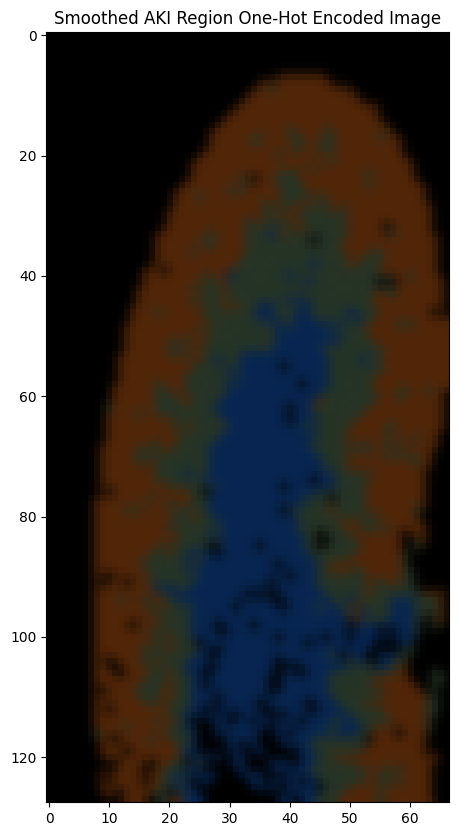

In [145]:
# smooth the image with a gaussian filter
from scipy.ndimage import gaussian_filter
img2 = gaussian_filter(img2, sigma=1)

#plot the smoothed image
plt.imshow(img2)
plt.title('Smoothed AKI Region One-Hot Encoded Image')
plt.show()

Note that this is an RGB image has been created as an NxMx3 matrix with values ranging from 0 to 1.


(128, 66, 3)
0.0
0.3222549782463051
(128, 67, 3)
0.0
0.3222967257412841
0.0
1.0
0.0
1.0


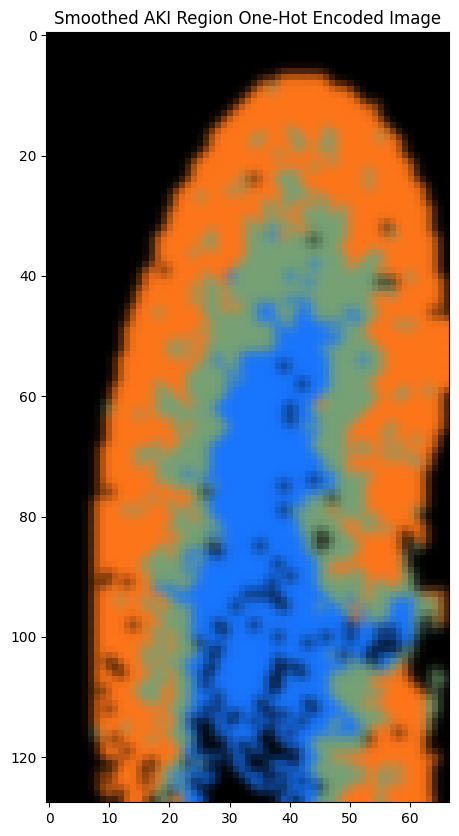

In [86]:
print(img1.shape)
print(img1.min())
print(img1.max())

print(img2.shape)
print(img2.min())
print(img2.max())

# normalize
img1 = STalign.normalize(img1)
print(img1 .min())
print(img1.max())

# normalize
img2 = STalign.normalize(img2)
print(img2 .min())
print(img2.max())

#plot the smoothed image
plt.imshow(img2)
plt.title('Smoothed AKI Region One-Hot Encoded Image')
plt.show()

We will transpose `img1` and `img2` to be a 3xNxM matrix for downstream analyses. We will also create some variances `Yimg1` and `Ximg1` and `Yimg2` and `Ximg2`to keep track of the image size.


In [146]:
img1= img1.transpose(2,0,1)
print(img1.shape)

Yimg1 = np.array(range(img1.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
Ximg1 = np.array(range(img1.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
extent1 = STalign.extent_from_x((Yimg1,Ximg1))

img2= img2.transpose(2,0,1)
print(img2.shape)

Yimg2 = np.array(range(img2.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
Ximg2 = np.array(range(img2.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
extent2 = STalign.extent_from_x((Yimg2,Ximg2))

(3, 128, 66)
(3, 128, 67)


Now we will perform our alignment. There are many parameters that can be tuned for performing this alignment. If we don't specify parameters, defaults will be used. 

/Users/kalenclifton/.local/share/virtualenvs/STalign-wXTCUYXW/lib/python3.10/site-packages/STalign/STalign.py:1043: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L = torch.tensor(L,device=device,dtype=dtype,requires_grad=True)
/Users/kalenclifton/.local/share/virtualenvs/STalign-wXTCUYXW/lib/python3.10/site-packages/STalign/STalign.py:1044: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T = torch.tensor(T,device=device,dtype=dtype,requires_grad=True)
/Users/kalenclifton/.local/share/virtualenvs/STalign-wXTCUYXW/lib/python3.10/site-packages/STalign/STalign.py:1301: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axE[2].set_yscale('log')


CPU times: user 35 s, sys: 760 ms, total: 35.8 s
Wall time: 34.9 s


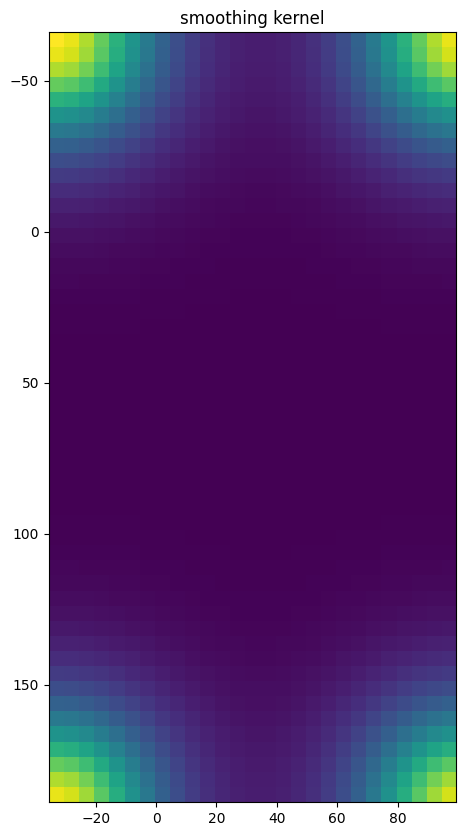

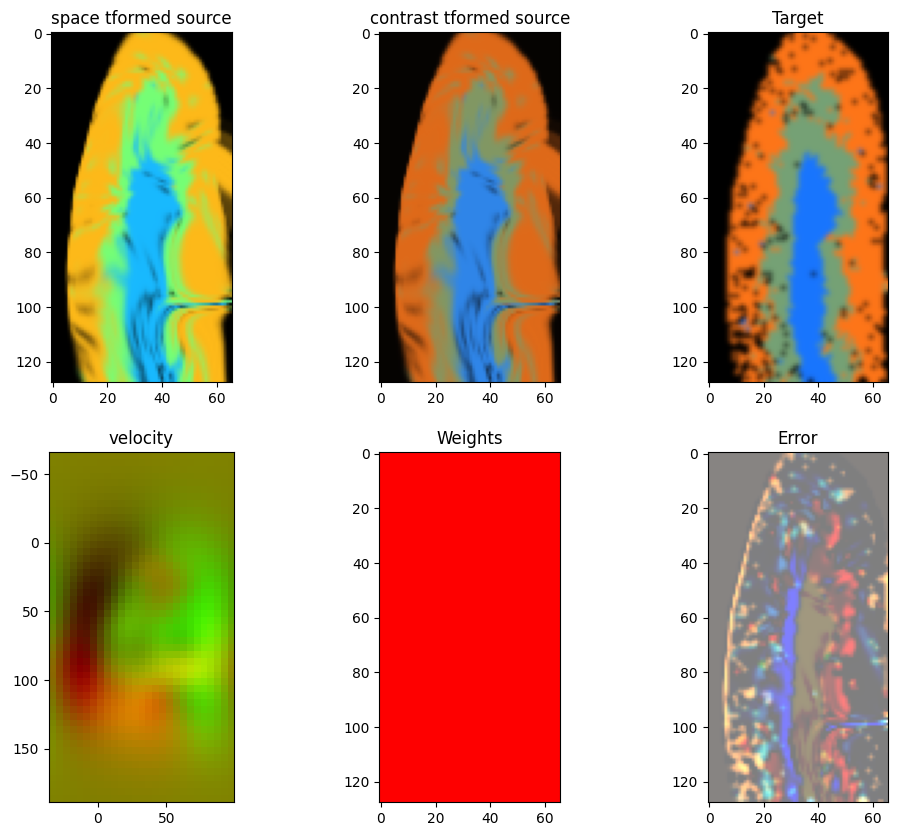

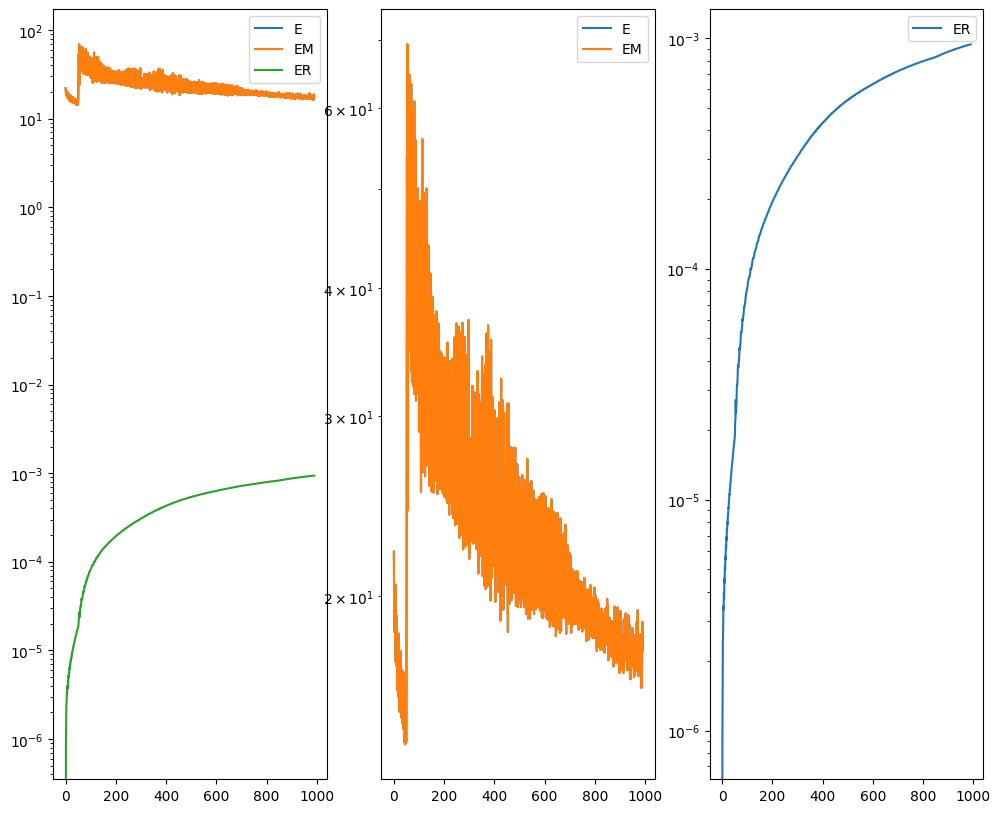

In [147]:
%%time

# run LDDMM
# specify device (default device for STalign.LDDMM is cpu)
if torch.cuda.is_available():
    device = 'cuda:0'
else:
    device = 'cpu'

# keep all other parameters default
params = {  'a': 10,
            'niter': 1000,
            #'diffeo_start': 1001,
            'device':device,
            'muB': torch.tensor([0,0,0]), # black is background in target
            #'muA': torch.tensor([1,1,1]) # use white as artifact 
            #'epV': 50
          }

#Ifoo = np.vstack((I, I, I)) # make RGB instead of greyscale
#Jfoo = np.vstack((J, J, J)) # make RGB instead of greyscale
#out = STalign.LDDMM([YI,XI],Ifoo,[YJ,XJ],Jfoo,**params)
out = STalign.LDDMM([Yimg2,Ximg2],img2,[Yimg1,Ximg1],img1,**params)

In [148]:
# get necessary output variables
A = out['A']
v = out['v']
xv = out['xv']

Plots generated throughout the alignment can be used to give you a sense of whether the parameter choices are appropriate and whether your alignment is converging on a solution.

We can also evaluate the resulting alignment by applying the transformation to visualize how our source and target images were deformed to achieve the alignment. 

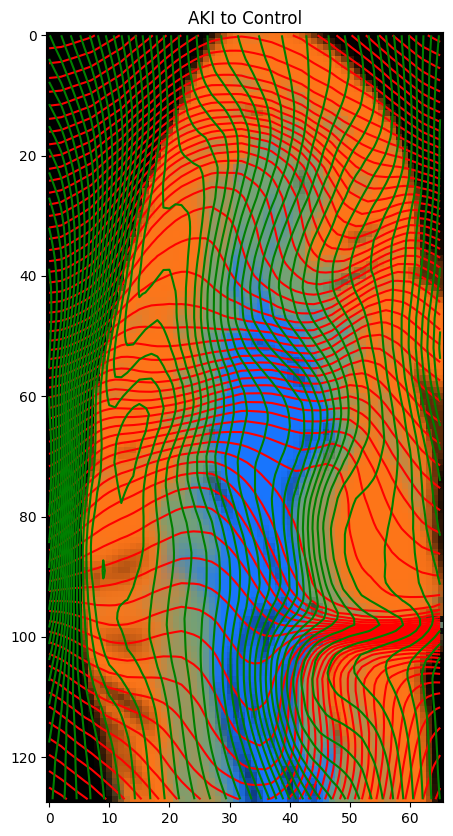

In [154]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[Yimg1,Ximg1],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[Yimg2,Ximg2],img2,[Yimg1,Ximg1])

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-200,200,2)
ax.contour(Ximg1,Yimg1,phii[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(Ximg1,Yimg1,phii[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('AKI to Control')
ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extent1)

Note that because of our use of LDDMM, the resulting transformation is invertible.

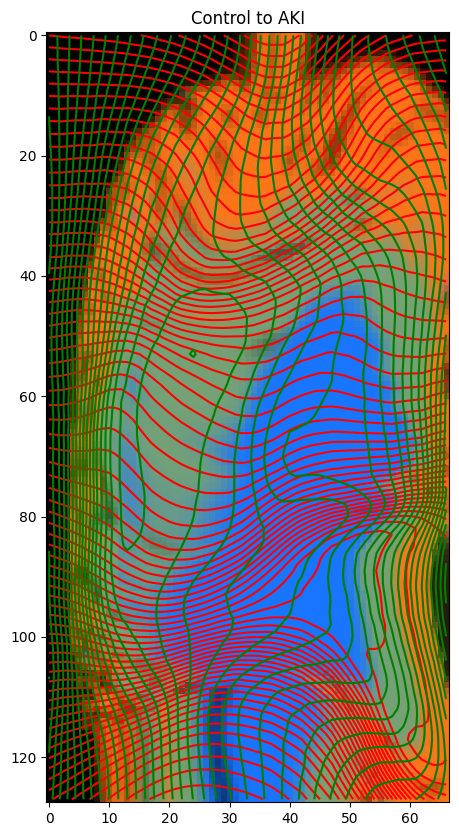

In [155]:
# transform is invertible
phi = STalign.build_transform(xv,v,A,XJ=[Yimg2,Ximg2],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[Yimg1,Ximg1],img1,[Yimg2,Ximg2])

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-200,200,2)
ax.contour(Ximg2,Yimg2,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(Ximg2,Yimg2,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('Control to AKI')
ax.imshow(phiiJ.permute(1,2,0)/torch.max(phiiJ),extent=extent2)

Finally, we can apply our STalign transform to the original sets of single cell centroid positions (with initial affine transformation) to achieve their new aligned positions.

In [167]:
# apply transform to original points with initial affine transformation
#tpointsI= STalign.transform_points_source_to_target(xv,v,A, np.stack([yI_L_T, xI_L_T], 1))
# apply transform to original points
[yI, xI] = df2['x'].values, df2['y'].values
[yJ, xJ] = df1['x'].values, df1['y'].values

#transform from double to long for STalign.transform later
yI = yI.astype(np.float64)
xI = xI.astype(np.float64)
yJ = yJ.astype(np.float64)
xJ = xJ.astype(np.float64)

tpointsI= STalign.transform_points_source_to_target(xv,v,A, np.stack([yI, xI], 1))

#switch from row column coordinates (y,x) to (x,y)
xI_LDDMM = tpointsI[:,1]
yI_LDDMM = tpointsI[:,0]

And we can visualize the results.

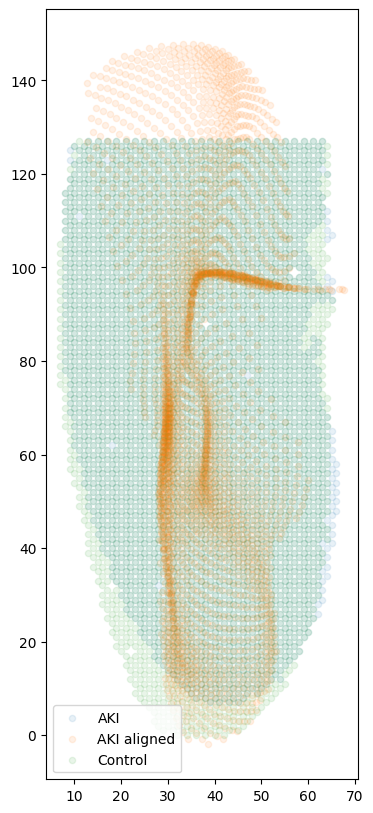

In [168]:
# plot results
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=20,alpha=0.1, label='AKI')
ax.scatter(xI_LDDMM,yI_LDDMM,s=20,alpha=0.1, label = 'AKI aligned')
ax.scatter(xJ,yJ,s=20,alpha=0.1, label='Control')

lgnd = plt.legend(scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([20.0])

ax.set_aspect('equal')

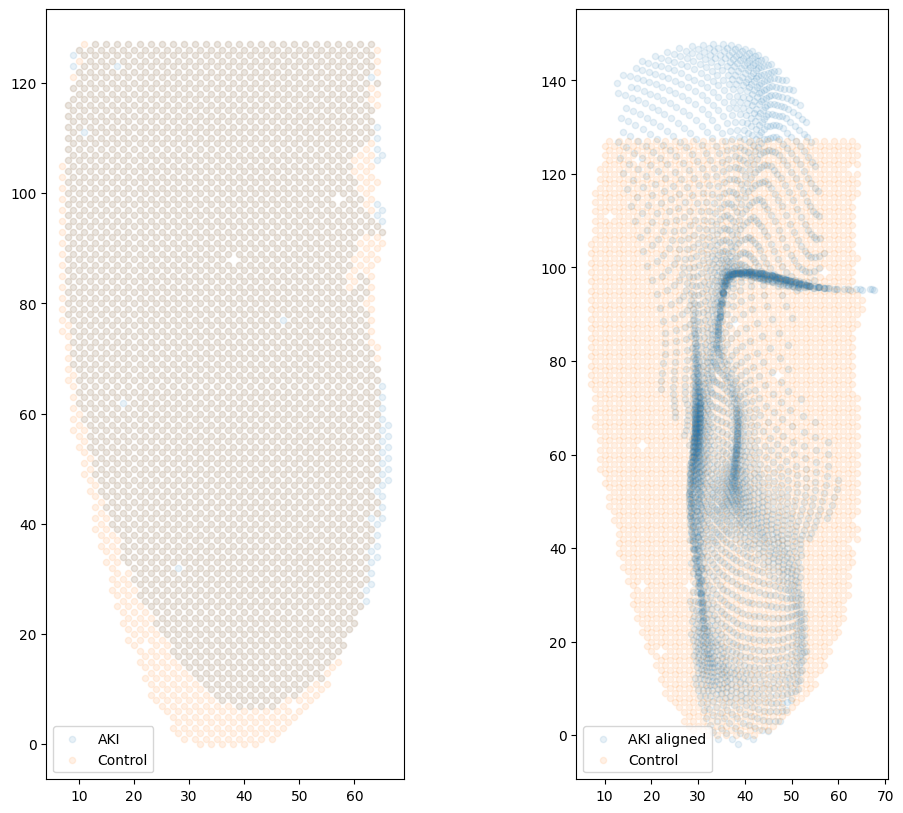

In [169]:
fig,ax = plt.subplots(1,2)
#ax[0].scatter(xI_L_T,yI_L_T,s=20,alpha=0.1, label='source with initial affine transformation')
ax[0].scatter(xI,yI,s=20,alpha=0.1, label='AKI')
ax[0].scatter(xJ,yJ,s=20,alpha=0.1, label='Control')
ax[1].scatter(xI_LDDMM,yI_LDDMM,s=20,alpha=0.1, label = 'AKI aligned') 
ax[1].scatter(xJ,yJ,s=20,alpha=0.1, label='Control')

lgnd = ax[0].legend(scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([20.0])

lgnd = ax[1].legend(scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([20.0])

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

And save the new aligned positions by appending to our original data

In [ ]:
df3 = pd.DataFrame(

    {

        "aligned_x": xI_LDDMM,

        "aligned_y": yI_LDDMM,

    },


)

results = pd.concat([df1, df3], axis=1)
results.head()

,1.306400000000000006e+01,6.086000000000000298e+00,aligned_x,aligned_y
0,12.116,7.015,15.474331,5.778815
1,13.945,6.999,17.303186,5.762786
2,12.987,7.011,16.345261,5.774801
3,15.011,7.984,18.368953,6.747827
4,12.050,8.018,15.408186,6.781876


We will finally create a compressed `.csv.gz` file

In [ ]:
results.to_csv('../visium_data/slice1_coor_STalign_to_slice2_coor_affine_only.csv.gz',
               compression='gzip')